In [1]:
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [7]:
# Seperate X and y
X, y = df.iloc[:,0:-1], df.iloc[:,-1]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print(f'X_train: {X_train.shape} X_test: {X_test.shape}')

X_train: (712, 3) X_test: (179, 3)


In [11]:
X_train.isnull().mean()*100

Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64

## Using Numpy

In [12]:
# Imputing missing values by Mean/Median
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)


X_train['Fare_99'] = X_train['Fare'].fillna(99)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [13]:
X_train

,Age,Fare,Family,Age_99,Age_minus1,Fare_99,Fare_minus1
331,45.5,28.5000,0,45.5,45.5,28.5000,28.5000
733,23.0,13.0000,0,23.0,23.0,13.0000,13.0000
382,32.0,7.9250,0,32.0,32.0,7.9250,7.9250
704,26.0,7.8542,1,26.0,26.0,7.8542,7.8542
813,6.0,31.2750,6,6.0,6.0,31.2750,31.2750
...,...,...,...,...,...,...,...
106,21.0,7.6500,0,21.0,21.0,7.6500,7.6500
270,NaN,31.0000,0,99.0,-1.0,31.0000,31.0000
860,41.0,NaN,2,41.0,41.0,99.0000,-1.0000
435,14.0,120.0000,3,14.0,14.0,120.0000,120.0000


In [14]:
# Checking change in Variance
print(f'Original Age Variance: {X_train['Age'].var()}')
print(f'Age Variance After 99 Imputation : {X_train['Age_99'].var()}')
print(f'Age Variance After -1 Imputation: {X_train['Age_minus1'].var()}')
print('-'*50)
print(f'Original Fare Variance: {X_train['Fare'].var()}')
print(f'Fare Variance After 99 Imputation : {X_train['Fare_99'].var()}')
print(f'Fare Variance After -1 Imputation: {X_train['Fare_minus1'].var()}')

Original Age Variance: 210.2517072477435
Age Variance After 99 Imputation : 932.9665366701432
Age Variance After -1 Imputation: 315.9955036260055
--------------------------------------------------
Original Fare Variance: 2761.0314349486343
Fare Variance After 99 Imputation : 2833.708690936761
Fare Variance After -1 Imputation: 2675.2394049177024


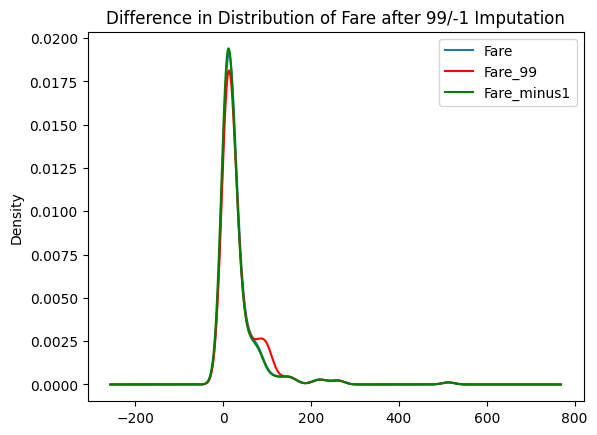

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.title('Difference in Distribution of Fare after 99/-1 Imputation')
X_train['Fare'].plot.density(ax=ax)

X_train['Fare_99'].plot.density(ax=ax, color='red')

X_train['Fare_minus1'].plot.density(ax=ax, color='green')

plt.legend()
plt.show()

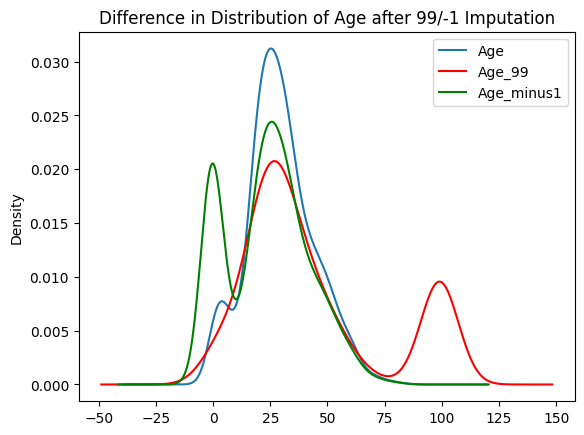

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.title('Difference in Distribution of Age after 99/-1 Imputation')
X_train['Age'].plot.density(ax=ax)

X_train['Age_99'].plot.density(ax=ax, color='red')

X_train['Age_minus1'].plot.density(ax=ax, color='green')

plt.legend()
plt.show()

In [18]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_99,Fare_minus1
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,75.273024,69.137162
Fare,75.481375,2761.031435,18.599163,-111.965046,135.785804,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-6.941982,-5.034556,17.603852,17.684447
Age_99,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-116.528480,-101.137070
Age_minus1,210.251707,135.785804,-5.034556,-166.460682,315.995504,138.114503,124.270305
Fare_99,75.273024,2761.031435,17.603852,-116.528480,138.114503,2833.708691,2514.109946
Fare_minus1,69.137162,2761.031435,17.684447,-101.137070,124.270305,2514.109946,2675.239405


In [19]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_99,Fare_minus1
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.091016,0.085422
Fare,0.091482,1.000000,0.207193,-0.069365,0.145071,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.135079,-0.168329,0.196548,0.203212
Age_99,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.071667,-0.064017
Age_minus1,1.000000,0.145071,-0.168329,-0.306576,1.000000,0.145956,0.135159
Fare_99,0.091016,1.000000,0.196548,-0.071667,0.145956,1.000000,0.913115
Fare_minus1,0.085422,1.000000,0.203212,-0.064017,0.135159,0.913115,1.000000


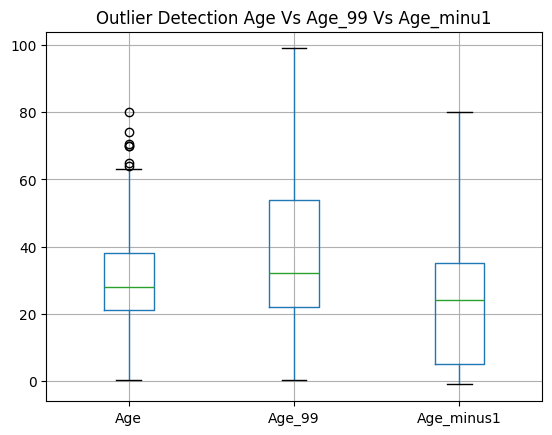

In [20]:
plt.title('Outlier Detection Age Vs Age_99 Vs Age_minu1')
X_train[['Age', 'Age_99', 'Age_minus1']].boxplot()
plt.show()

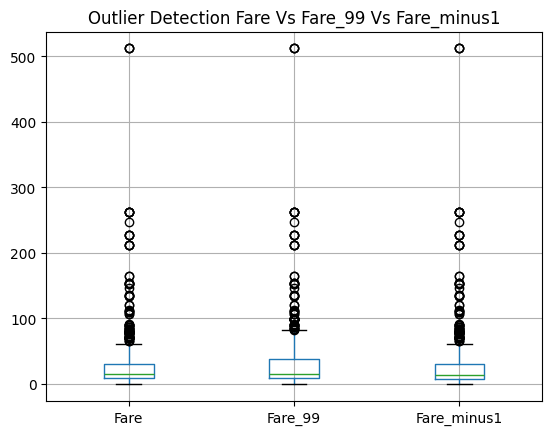

In [21]:
plt.title('Outlier Detection Fare Vs Fare_99 Vs Fare_minus1')
X_train[['Fare', 'Fare_99', 'Fare_minus1']].boxplot()
plt.show()

## Using Sklearn's SimpleImputer

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
imputer_99 = SimpleImputer(strategy='constant', fill_value=99)
imputer_999 = SimpleImputer(strategy='constant', fill_value=999)

In [25]:
trf = ColumnTransformer([
    ('imputer_99', imputer_99, ['Age']),
    ('imputer_999', imputer_999, ['Fare'])
], remainder='passthrough')

In [26]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer_99',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer_999',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [28]:
print(trf.named_transformers_['imputer_99'].statistics_)
print(trf.named_transformers_['imputer_999'].statistics_)

[99.]
[999.]


In [29]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [30]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    , 999.    ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))

In [31]:
X_test

array([[9.900000e+01, 1.524580e+01, 2.000000e+00],
       [3.100000e+01, 1.050000e+01, 0.000000e+00],
       [2.000000e+01, 7.925000e+00, 0.000000e+00],
       [6.000000e+00, 3.300000e+01, 1.000000e+00],
       [1.400000e+01, 1.124170e+01, 1.000000e+00],
       [2.600000e+01, 7.885000e+01, 0.000000e+00],
       [9.900000e+01, 7.750000e+00, 0.000000e+00],
       [1.600000e+01, 1.800000e+01, 2.000000e+00],
       [1.600000e+01, 7.750000e+00, 0.000000e+00],
       [1.900000e+01, 2.628330e+01, 2.000000e+00],
       [3.700000e+01, 5.310000e+01, 1.000000e+00],
       [4.400000e+01, 8.050000e+00, 0.000000e+00],
       [9.900000e+01, 2.546670e+01, 4.000000e+00],
       [3.000000e+01, 7.225000e+00, 0.000000e+00],
       [3.600000e+01, 1.300000e+01, 0.000000e+00],
       [1.600000e+01, 3.940000e+01, 1.000000e+00],
       [4.200000e+01, 5.255420e+01, 1.000000e+00],
       [9.900000e+01, 7.829200e+00, 0.000000e+00],
       [2.700000e+01, 1.300000e+01, 0.000000e+00],
       [4.700000e+01, 5.200000e